In [17]:
import torch
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.notebook import trange
import os
import urllib
from tqdm import tqdm
from os import listdir
import pathlib
from torchvision.io import decode_image
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
from torchvision.transforms import v2

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# If there is hardware acceleration use it

In [18]:
# https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)

mps


# How to read the data
* Reading the data
* Putting the image stright into ram is not a good idea
* I think maybe I will be using a CVS file that store the classification of the image and the path to the image. 

In [19]:
# https://www.geeksforgeeks.org/python-list-files-in-a-directory/
# https://stackoverflow.com/questions/3430372/how-do-i-get-the-full-path-of-the-current-files-directory
# https://stackoverflow.com/questions/431684/how-do-i-change-the-working-directory-in-python
path = pathlib.Path().resolve()
dir_list = os.listdir(path)
if 'train' in dir_list:
    train_dir_path = os.path.join(os.path.join(path,'train'),'train')
else:
    raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"" + os.path.join(path,'train') + "\"")

# Setting up transform for the image
* https://www.kaggle.com/code/leifuer/intro-to-pytorch-loading-image-data
* https://pytorch.org/vision/0.9/transforms.html

In [ ]:
# transform = transforms.Compose()
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224,244)),
    transforms.ToTensor(),
])

# Import image
* https://www.kaggle.com/code/leifuer/intro-to-pytorch-loading-image-data

In [21]:

dataset = datasets.ImageFolder(train_dir_path,transform=transform)

# Split dataset
* https://discuss.pytorch.org/t/how-to-split-dataset-into-test-and-validation-sets/33987

In [22]:
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.9,0.1])

# Data loaders

In [23]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Image augmentation
* Adversarial attack (Suggested by Johnson)
* Flip
* Inverse
* Rotate
* Zoom

### Resourse on doing augmentation
* https://pytorch.org/vision/main/transforms.html

# Image augmentation function
* https://pytorch.org/vision/main/transforms.html

In [45]:
AUGMENTATIONS: list[v2.Transform] = [
    v2.GaussianNoise(),
    v2.RandomSolarize(threshold=0.1),
    v2.ColorJitter(),
    v2.RandomRotation(degrees=90),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.RandomInvert(),
]

NUM_AUGMENTATIONS: int = 4

In [32]:
# TODO make the random number determinstic via a seed
def getRandomAugments() -> list[v2.Transform]:
    augs: list[v2.Transform] = []
    for _ in range(NUM_AUGMENTATIONS):
        rand: int = round(random.random() * len(AUGMENTATIONS))
        augs.append(AUGMENTATIONS[rand - 1])
    
    return augs

getRandomAugments()

[RandomSolarize(p=0.5, threshold=0.5),
 GaussianNoise(mean=0.0, sigma=0.1, clip=True),
 GaussianNoise(mean=0.0, sigma=0.1, clip=True),
 RandomVerticalFlip(p=0.5)]

In [47]:
# Horizontally flip each image at the given probability
def augment_images(images: torch.Tensor) -> torch.Tensor:
    augmented_images: list[torch.Tensor] = []
    for image in images:
        augments: list[v2.Transform] = getRandomAugments()
        for i in range(NUM_AUGMENTATIONS):
            transforms: v2.Transform = v2.Compose([
                v2.RandomResizedCrop(size=(224, 224), antialias=True),
                augments[i],
                # v2.ToDtype(torch.float32, scale=True),
                # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
            img: torch.Tensor = transforms(image)
            augmented_images.append(img)
        

    print(np.array(augmented_images))
    return torch.from_numpy(np.array(augmented_images))

In [30]:
print(test_dataset.dataset, test_dataset.indices)

Dataset ImageFolder
    Number of datapoints: 1000
    Root location: /Users/thomas/Documents/GitHub/CSE_144_Final_Project/Final_Project/train/train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 244), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           ) [256, 526, 70, 461, 454, 634, 393, 794, 520, 156, 966, 675, 598, 462, 13, 90, 875, 55, 45, 643, 630, 753, 572, 19, 61, 104, 581, 602, 754, 665, 105, 435, 662, 559, 14, 863, 539, 519, 761, 232, 554, 441, 574, 747, 653, 877, 224, 293, 556, 358, 898, 806, 712, 254, 97, 710, 736, 621, 146, 465, 431, 330, 395, 129, 741, 579, 115, 111, 549, 80, 222, 617, 969, 809, 527, 776, 151, 822, 870, 240, 277, 7, 918, 466, 400, 557, 566, 846, 985, 481, 219, 318, 894, 2, 770, 335, 284, 638, 96, 455]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99996626..0.83811224].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.95766085].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1308747..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the va

[[[[-0.02745098 -0.02745098 -0.02745098 ... -0.5453781  -0.5372549
    -0.5372549 ]
   [-0.02745098 -0.02745098 -0.02745098 ... -0.5453781  -0.5372549
    -0.5372549 ]
   [-0.02983193 -0.02983193 -0.03044843 ... -0.53991467 -0.53487396
    -0.53487396]
   ...
   [ 0.00392163  0.00392163  0.00392163 ...  0.00392163  0.00392163
     0.00392163]
   [ 0.00392163  0.00392163  0.00392163 ...  0.00392163  0.00392163
     0.00392163]
   [ 0.00392163  0.00392163  0.00392163 ...  0.00392163  0.00392163
     0.00392163]]

  [[ 0.05098045  0.05098045  0.05098045 ... -0.5709383  -0.56078434
    -0.56078434]
   [ 0.05098045  0.05098045  0.05098045 ... -0.5709383  -0.56078434
    -0.56078434]
   [ 0.04621854  0.04621854  0.04621854 ... -0.5648584  -0.5584034
    -0.5584034 ]
   ...
   [ 0.01176476  0.01176476  0.01176476 ...  0.0196079   0.0196079
     0.0196079 ]
   [ 0.01176476  0.01176476  0.01176476 ...  0.0196079   0.0196079
     0.0196079 ]
   [ 0.01176476  0.01176476  0.01176476 ...  0.0196079

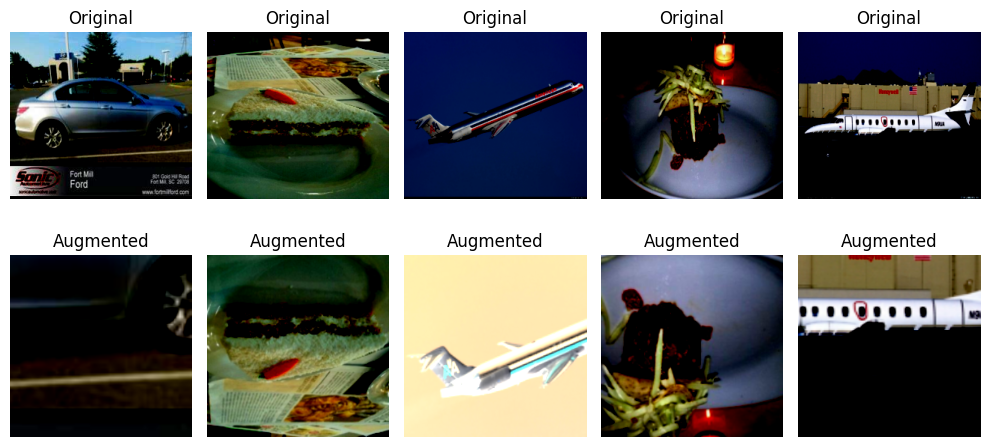

In [48]:
# Visualize some original and augmented images
plt.figure(figsize=(10, 5))
# Get a batch of images from the test dataset
images, _ = next(iter(test_loader))
augmented_batch = augment_images(images[:5])  # Get 5 images and their augmentations

# Plot original and augmented images
for i in range(5):
    # Original image
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].permute(1, 2, 0).cpu())  # Convert from CxHxW to HxWxC
    plt.title("Original")
    plt.axis("off")

    # Augmented image
    plt.subplot(2, 5, i + 6)  # i + 1 + 5
    plt.imshow(augmented_batch[i*4].permute(1, 2, 0).cpu())
    plt.title("Augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Learning transfer learning from exercise
* https://colab.research.google.com/drive/1dbn_Bhb52ekBf-a4twFOJUSlLjzTw5gs?usp=sharing

In [83]:
import torchvision.models as model
base_model = model.regnet_y_32gf(weights=model.RegNet_Y_32GF_Weights.IMAGENET1K_V2).to(device=device)

In [ ]:
# Freeze the base model parameters (optional for feature extraction)
for param in base_model.parameters():
    param.requires_grad = False

In [ ]:
# Define a new classification head
class RegNetHead(nn.Module):
    def __init__(self, num_classes=100):
        super(RegNetHead, self).__init__()
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3712, 1856),  # RegNet_Y_32GF has 3712 output features
            nn.ReLU(),
            nn.Linear(1856, num_classes),  # RegNet_Y_32GF has 1856 output features
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

# Setting up the nn
* This code is from https://colab.research.google.com/drive/1dbn_Bhb52ekBf-a4twFOJUSlLjzTw5gs#scrollTo=3kTYygi258Yv
* https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html#torch.optim.lr_scheduler.ReduceLROnPlateau

In [ ]:
# Initialize the network and optimizer
# base_model = models.vgg16(pretrained=True).to(device=device)
net = RegNetHead().to(device=device)
# optimizer = optim.Adam(net.parameters(), lr=0.001)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
scheduler = torch.ReduceLROnPlateau(optimizer, 'min')
criterion = nn.CrossEntropyLoss()

# Acuracy calculation

In [ ]:
# Function to calculate accuracy
def accuracy(loader, model, base_model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            images, labels = data
            with torch.no_grad():
              # The REG is frozen
              reg_features = base_model.features(images.to(device=device))
            outputs = net(reg_features)
            _, predicted = torch.max(outputs.cpu().data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

In [60]:
print(train_dataset.dataset)
print(train_dataset.indices)
print(len(train_dataset.indices))

Dataset ImageFolder
    Number of datapoints: 1000
    Root location: /Users/thomas/Documents/GitHub/CSE_144_Final_Project/Final_Project/train/train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 244), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )
[542, 618, 816, 68, 94, 215, 60, 585, 942, 165, 968, 829, 186, 661, 525, 982, 315, 52, 641, 797, 49, 40, 731, 260, 467, 563, 251, 595, 299, 187, 742, 997, 531, 802, 459, 349, 695, 159, 334, 50, 546, 196, 873, 181, 795, 433, 807, 691, 53, 624, 820, 440, 338, 327, 562, 374, 311, 197, 20, 377, 786, 184, 512, 859, 406, 271, 911, 629, 951, 482, 567, 633, 720, 728, 250, 84, 583, 396, 418, 297, 534, 245, 480, 170, 910, 600, 497, 382, 891, 67, 767, 732, 161, 234, 185, 775, 825, 926, 853, 31, 83, 664, 471, 642, 137, 26, 163, 778, 885, 553, 265, 979, 511, 640, 93, 429, 560, 946, 307, 99, 759, 470, 967, 934, 632

# Training

In [ ]:
class Trainer:
    def __init__(self, model, optimizer, lambda_reg=0.0):
        self.model = model
        self.optimizer = optimizer
        self.lambda_reg = lambda_reg

    def train(self, x_train, y_train, x_val, y_val, epochs=10, batch_size=32):
        losses_train, losses_val = [], []
        accs_val = []

        num_batches = (x_train.shape[0] + batch_size - 1) // batch_size

        for epoch_id in tqdm(range(epochs)):
            epoch_loss = 0

            indices = train_dataset.indices
            np.random.shuffle(indices)
            x_train, y_train = train_dataset[indices][0], train_dataset[indices][1]

            for batch in range(num_batches):
                # Get the batch data 

                start_index = batch * batch_size
                end_index = min(start_index + batch_size, x_train.shape[0])

                x_batch = x_train[start_index: end_index]
                y_batch = y_train[start_index: end_index]


                # Apply augmentation and normalization 

                x_batch, y_batch = augment_images(x_batch, y_batch)              
                # x_batch = normalize_images(x_batch)

                # x_batch = x_batch.reshape(x_batch.shape[0], -1)
                # y_pred = self.model.forward(x_batch)

                # ===========================
                # Setting up to run the model
                # ===========================

                loss = criterion(y_pred, y_batch)

                # dW1, db1, dW2, db2 = cross_entropy_backward(y_pred, y_batch, x_batch, self.model)

                # Update parameters using the optimizer 

                # params = self.model.W1, self.model.b1, self.model.W2, self.model.b2
                # grads = dW1, db1, dW2, db2
                # params = self.optimizer.update(params, grads)
                

                epoch_loss += loss

            # Print epoch statistics
            loss_train = epoch_loss / num_batches
            loss_val, acc_val = self.evaluate(x_val, y_val)
            losses_train.append(loss_train)
            losses_val.append(loss_val)
            accs_val.append(acc_val)
            print(f"Epoch {epoch_id + 1}/{epochs}, Training Loss: {loss:.4f}, Validation Loss: {loss_val:.4f}, Validation ACC: {acc_val:.4f}")

        return losses_train, losses_val, accs_val

# Stopping point

# Get save path

In [ ]:
path = pathlib.Path().resolve()
dir_list = os.listdir(path)
if 'model' in dir_list:
    model_dir_path = os.path.join(path,'model')
else:
    raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"")

model_path_list = os.listdir(model_dir_path)
timestr = time.strftime("%Y%m%d_%H%M%S")
model_file_name = os.path.join(model_dir_path,timestr) + ".pt"

# Save it

In [ ]:
torch.save(net.state_dict(),model_file_name)